# Investigating the pushT play dataset — start frames with multi-modal futures

The goal: **find real start frames whose continuation is genuinely ambiguous**, so a
rollout experiment can be conditioned on them and checked for whether the sampler
recovers the modes the data actually contains.

The dataset (`/home/mim-server/datasets/pushT/h5/play`) stores no state — only
`images (n, 256, 256, 3)` and `actions (n, 3)` per shard, one continuous ~20-minute
teleop session per shard, 13 shards, 77,698 frames at 5 Hz. So the physical state is
recovered here by colour segmentation: the red T's pose and the black end-effector
ball's position. Nothing in sections 1–8 touches the world model.

**Method.** Reduce every frame to `(cx, cy, φ, ex, ey)`. Two frames *match* when those
agree to within a few pixels. Then measure how far their futures drift apart. Where a
context is matched by several sessions whose outcomes split into distinct clusters,
that frame is a multi-modal start point.

**What was found** (numbers reproduced by the cells below):

| | |
|---|---|
| cross-session pairs within 8 px | 102,774, covering 47,025 distinct frames |
| divergence of matched futures at 2 s | 22.4 px vs 40.2 px for random pairs — the frame removes only 44% of the uncertainty |
| effect of 1.4 s of extra history (paired) | −8% at 2 s, −2% at 8 s |
| next action at matched contexts | \|Δa\|/\|a\| = 0.78; opposite direction in 24% of pairs |
| segmentation noise floor | 0.35 px |

Sections:
1. Setup · 2. Frame descriptors · 3. Extract all frames · 4. How ambiguous is one
frame? · 5. Find multi-modal groups · 6. Inspect a group · 7. Empirical modes ·
8. Export · 9. Hand-off to rollouts

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import json, os, sys
from pathlib import Path
from multiprocessing import get_context

import numpy as np
import h5py
import cv2
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

DATA_DIR  = Path('/home/mim-server/datasets/pushT/h5/play')
CACHE_DIR = Path.home() / '.cache' / 'pushT-play-analysis'   # descriptor cache, outside the repo
OUT_DIR   = Path('.')                                        # exports land next to this notebook
CACHE_DIR.mkdir(parents=True, exist_ok=True)

N_SHARDS = 13
DT   = 0.2     # seconds per frame (scripts/config/dataset/pushT.yaml)
RHO  = 20.0    # px per radian — the T's radius of gyration, so rotations and
               # translations are compared in the same unit: how far the T's surface moves

def shard_path(s):
    return DATA_DIR / f'shard_{s:04d}.h5'

lengths = []
for s in range(N_SHARDS):
    with h5py.File(shard_path(s), 'r') as f:
        lengths.append(int(f['episode_lengths'][0]))
print('frames per shard:', lengths)
print(f'total {sum(lengths)} frames = {sum(lengths)*DT/60:.0f} min at {1/DT:.0f} Hz')

frames per shard: [6609, 6013, 4513, 6014, 6014, 6183, 6013, 5631, 6310, 6297, 6014, 6013, 6074]
total 77698 frames = 259 min at 5 Hz


## 2. Frame descriptors

`t_pose` reuses the red HSV gates from `dreamerv4uwm.planning.reward.score_t_centered`, so
the T found here is the same T the planning rewards score. Two additions: the white AprilTag
stickers are closed over before taking moments, and `conf` reports how decisively the
crossbar half was identified — the heading is the principal axis with its 180° ambiguity
resolved by which half spreads wider, and `conf` near 1.0 means that call was a coin flip.

`ee_pos` finds the black ball. The arm's rod is black too, but thin: a 9×9 opening erases it
and leaves the ball. Among survivors the roundest blob of plausible size wins, which rejects
the dark table edge when it leaks into the ROI.

In [2]:
ROI_Y0, ROI_Y1 = 52, 238    # table surface only (top rows are the pillar, below 238 the table edge)
ROI_X0, ROI_X1 = 4, 252
_EE_KER = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))


def _heading(xs, ys):
    """Heading in (-pi, pi] pointing toward the crossbar, plus a confidence ratio.

    The major axis of a T-shaped mask is its stem; splitting the mask at the centroid
    along that axis, the crossbar half spreads wider across it. `conf` is the ratio of
    the two spreads — 1.0 means the two halves were indistinguishable.
    """
    x = xs.astype(np.float64) - xs.mean()
    y = ys.astype(np.float64) - ys.mean()
    _, evecs = np.linalg.eigh(np.cov(np.stack([x, y])))
    v = evecs[:, -1]                       # major (stem) axis
    perp = np.array([-v[1], v[0]])
    p = x * v[0] + y * v[1]                # along the stem
    q = x * perp[0] + y * perp[1]          # across it
    hi, lo = p > 0, p <= 0
    s_hi = float(q[hi].std()) if hi.sum() > 1 else 0.0
    s_lo = float(q[lo].std()) if lo.sum() > 1 else 0.0
    h = v if s_hi >= s_lo else -v          # point toward the wider (crossbar) half
    conf = max(s_hi, s_lo) / max(min(s_hi, s_lo), 1e-6)
    return float(np.arctan2(h[1], h[0])), float(conf)


def t_pose(rgb, s_min=90, v_min=60, hue_lo=12, hue_hi=168, min_area=100):
    """Red T -> {found, cx, cy, phi, conf, area, mask}."""
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lo1 = np.array([0, s_min, v_min], np.uint8);       hi1 = np.array([hue_lo, 255, 255], np.uint8)
    lo2 = np.array([hue_hi, s_min, v_min], np.uint8);  hi2 = np.array([180, 255, 255], np.uint8)
    mask = cv2.inRange(hsv, lo1, hi1) | cv2.inRange(hsv, lo2, hi2)
    mask[:ROI_Y0] = 0
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    n, lab, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n <= 1:
        return dict(found=False)
    i = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    if stats[i, cv2.CC_STAT_AREA] < min_area:
        return dict(found=False)
    comp = cv2.morphologyEx((lab == i).astype(np.uint8), cv2.MORPH_CLOSE,
                            np.ones((9, 9), np.uint8))     # fill the AprilTag stickers
    ys, xs = np.nonzero(comp)
    phi, conf = _heading(xs, ys)
    return dict(found=True, cx=float(xs.mean()), cy=float(ys.mean()),
                phi=phi, conf=conf, area=int(comp.sum()), mask=comp)


def ee_pos(rgb, v_max=70, min_area=40, max_area=900):
    """Black end-effector ball -> {found, ex, ey, area, mask}."""
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    dark = (hsv[..., 2] < v_max).astype(np.uint8)
    dark[:ROI_Y0] = 0; dark[ROI_Y1:] = 0
    dark[:, :ROI_X0] = 0; dark[:, ROI_X1:] = 0
    ball = cv2.morphologyEx(dark, cv2.MORPH_OPEN, _EE_KER)   # kills the thin rod
    n, lab, stats, cent = cv2.connectedComponentsWithStats(ball)
    best, best_score = None, -1.0
    for i in range(1, n):
        a = int(stats[i, cv2.CC_STAT_AREA])
        if not (min_area <= a <= max_area):
            continue
        w, h = int(stats[i, cv2.CC_STAT_WIDTH]), int(stats[i, cv2.CC_STAT_HEIGHT])
        score = (a / (w * h)) * (min(w, h) / max(w, h)) * min(a, 400) / 400.0   # round and big
        if score > best_score:
            best, best_score = i, score
    if best is None or best_score < 0.15:
        return dict(found=False)
    return dict(found=True, ex=float(cent[best][0]), ey=float(cent[best][1]),
                area=int(stats[best, cv2.CC_STAT_AREA]), mask=(lab == best).astype(np.uint8))


def annotate(rgb, label=None, ref=None):
    """Overlay the T centroid + heading (green), the EE (orange) and, if given, the
    T centroid at the start frame (white cross) with the displacement since (yellow)."""
    v = rgb.copy()
    t, e = t_pose(rgb), ee_pos(rgb)
    if ref is not None:
        cv2.drawMarker(v, (int(ref[0]), int(ref[1])), (255, 255, 255), cv2.MARKER_CROSS, 11, 1)
    if t['found']:
        c = (int(t['cx']), int(t['cy']))
        cv2.circle(v, c, 3, (0, 255, 0), -1)
        cv2.arrowedLine(v, c, (int(c[0] + 22*np.cos(t['phi'])), int(c[1] + 22*np.sin(t['phi']))),
                        (0, 255, 0), 2, tipLength=0.35)
        if ref is not None:
            cv2.line(v, (int(ref[0]), int(ref[1])), c, (255, 255, 0), 1)
    if e['found']:
        cv2.circle(v, (int(e['ex']), int(e['ey'])), 9, (0, 160, 255), 2)
    if label:
        cv2.rectangle(v, (0, 0), (rgb.shape[1]-1, 16), (0, 0, 0), -1)
        cv2.putText(v, label, (3, 12), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (255, 255, 255), 1, cv2.LINE_AA)
    return v

Sanity check — the detectors on a handful of frames. Look for the green arrow pointing at the crossbar (the flat top of the T) and the orange circle on the ball, not on the rod.

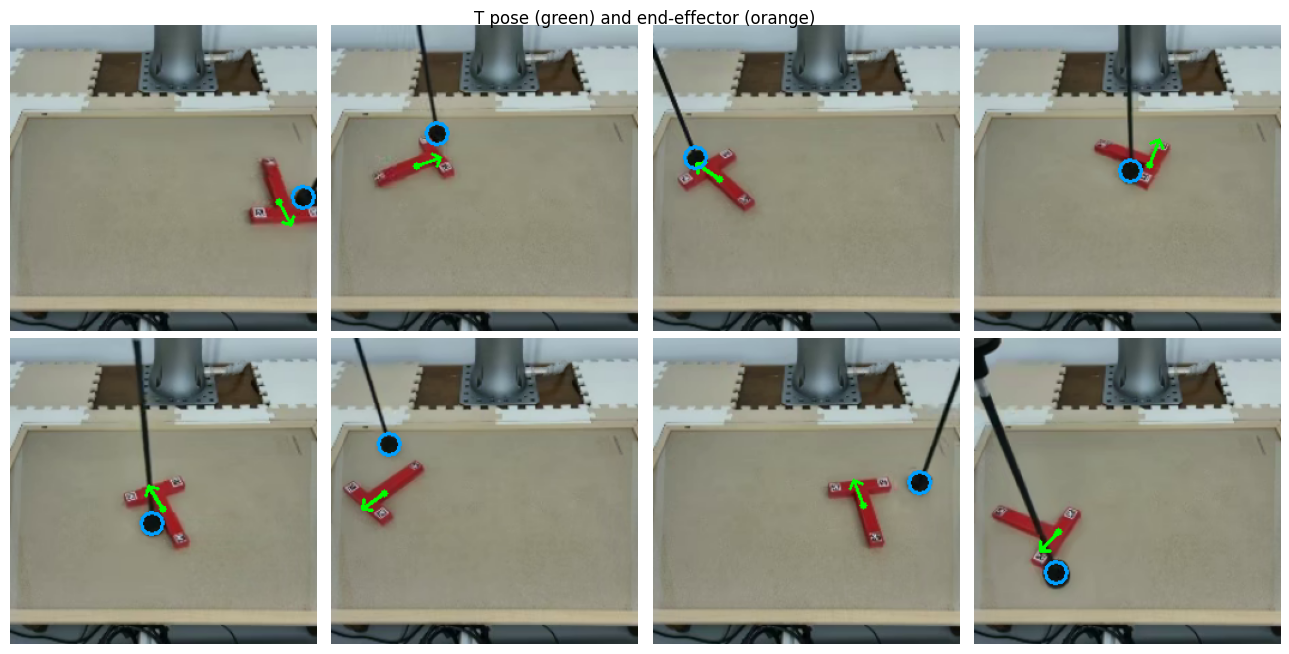

In [3]:
with h5py.File(shard_path(3), 'r') as f:
    check = f['images'][0, 1000:1400:50]

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, im in zip(axes.ravel(), check):
    ax.imshow(annotate(im)); ax.axis('off')
fig.suptitle('T pose (green) and end-effector (orange)', y=0.94)
plt.tight_layout(); plt.show()

## 3. Extract every frame

~20 s across 13 processes, then cached in `CACHE_DIR`. The record per frame is

`[t_found, cx, cy, phi, t_area, conf, e_found, ex, ey]`

In [4]:
CHUNK = 512   # frames per read = 4 HDF5 chunks. A chunk is 128 frames of gzip-4 (25 MB raw),
              # far above h5py's 1 MB chunk cache, so a frame-by-frame read re-inflates the whole
              # chunk every time: 60 ms/frame vs 0.6 ms/frame in slabs (measured, ~95x).
              # What matters is that reads stay aligned to 128, not that they are large:
              # aligned 128 and 512 are within 6% of each other, but 128 starting at 64
              # straddles two chunks per read and costs 2x.


def _run_shard(s):
    with h5py.File(shard_path(s), 'r') as f:
        n = int(f['episode_lengths'][0])
        acts = f['actions'][0][:n].astype(np.float32)
        rec = np.full((n, 9), np.nan, np.float32)
        for a in range(0, n, CHUNK):
            imgs = f['images'][0, a:min(a + CHUNK, n)]
            for k in range(imgs.shape[0]):
                t, e = t_pose(imgs[k]), ee_pos(imgs[k])
                r = rec[a + k]
                r[0] = t['found']
                if t['found']:
                    r[1], r[2], r[3], r[4], r[5] = t['cx'], t['cy'], t['phi'], t['area'], t['conf']
                r[6] = e['found']
                if e['found']:
                    r[7], r[8] = e['ex'], e['ey']
    return s, rec, acts


def load_states(force=False):
    """Per-frame descriptors for every shard: (recs, acts), cached on disk."""
    cache = CACHE_DIR / 'states.npz'
    if cache.exists() and not force:
        d = np.load(cache)
        return [d[f'rec_{s}'] for s in range(N_SHARDS)], [d[f'act_{s}'] for s in range(N_SHARDS)]
    with get_context('fork').Pool(N_SHARDS) as p:      # fork: _run_shard is defined in the notebook
        res = sorted(p.map(_run_shard, range(N_SHARDS)))
    out = {}
    for s, rec, act in res:
        out[f'rec_{s}'], out[f'act_{s}'] = rec, act
    np.savez_compressed(cache, **out)
    print('cached ->', cache)
    return [out[f'rec_{s}'] for s in range(N_SHARDS)], [out[f'act_{s}'] for s in range(N_SHARDS)]


recs, acts = load_states()
phis = [np.unwrap(r[:, 3]) for r in recs]     # continuous heading, so temporal deltas do not wrap
R = np.concatenate(recs)
print(f'T detected on {100*R[:,0].mean():.1f}% of frames, EE on {100*R[:,6].mean():.1f}%')
print('heading confidence percentiles (1/25/50/75):',
      np.percentile(R[R[:,0] > 0, 5], [1, 25, 50, 75]).round(2))

T detected on 100.0% of frames, EE on 97.8%
heading confidence percentiles (1/25/50/75): [1.03 1.66 2.13 2.55]


The noise floor: how much the measured T pose changes between consecutive frames while the end-effector is far away — i.e. while nothing is touching it. Everything below must be read against this number.

In [5]:
still = []
for s, r in enumerate(recs):
    ok = (r[:-1, 0] > 0) & (r[1:, 0] > 0) & (r[:-1, 6] > 0)
    far = np.hypot(r[:-1, 1] - r[:-1, 7], r[:-1, 2] - r[:-1, 8]) > 60
    dphi = (phis[s][1:] - phis[s][:-1] + np.pi) % (2*np.pi) - np.pi
    d = np.linalg.norm(np.stack([r[1:, 1] - r[:-1, 1], r[1:, 2] - r[:-1, 2], RHO*dphi], 1), axis=1)
    still.append(d[ok & far])
still = np.concatenate(still)
print(f'noise floor: p50={np.median(still):.2f}px  p90={np.percentile(still, 90):.2f}px  (n={len(still)})')

noise floor: p50=0.35px  p90=3.27px  (n=1785)


## 4. How much does one frame decide?

A **context** is what a policy sees at time `t`; an **outcome** is how the T actually moved
over the next `H` frames:

    c = (cx, cy, ρ·cosφ, ρ·sinφ, ex, ey)          o = (Δcx, Δcy, ρ·Δφ)

Two frames match when `‖c_i − c_j‖ < TAU`. Matches are kept only across different sessions,
or more than `SELF_GAP` frames apart within one session, so no pair is two neighbouring
frames of the same event.

In [6]:
MIN_CONF = 1.3     # drop frames where the heading was a coin flip
TAU      = 8.0     # px, context match radius
SELF_GAP = 250     # frames (50 s) — same-session matches must be at least this far apart

S, T, F = [], [], []
for s, r in enumerate(recs):
    ok = (r[:, 0] > 0) & (r[:, 6] > 0) & (r[:, 5] > MIN_CONF)
    idx = np.nonzero(ok)[0]
    S.append(np.full(idx.size, s)); T.append(idx)
    F.append(np.stack([r[idx, 1], r[idx, 2],
                       RHO*np.cos(phis[s][idx]), RHO*np.sin(phis[s][idx]),
                       r[idx, 7], r[idx, 8]], 1))
S, T, F = np.concatenate(S), np.concatenate(T), np.concatenate(F)
print(f'{len(F)} usable frames of {sum(len(r) for r in recs)}')


def outcomes(H, rows_S=S, rows_T=T):
    """(n, 3) T-pose displacement H frames ahead; NaN where the window runs off the end."""
    O = np.full((len(rows_S), 3), np.nan)
    for s in range(N_SHARDS):
        r = recs[s]; m = rows_S == s
        t = rows_T[m]; u = t + H
        good = (u < len(r)) & (r[np.clip(u, 0, len(r)-1), 0] > 0)
        rows = np.nonzero(m)[0][good]; t_, u_ = t[good], u[good]
        dphi = (phis[s][u_] - phis[s][t_] + np.pi) % (2*np.pi) - np.pi
        O[rows] = np.stack([r[u_, 1] - r[t_, 1], r[u_, 2] - r[t_, 2], RHO*dphi], 1)
    return O


pairs = np.array(sorted(cKDTree(F).query_pairs(TAU)))
i, j = pairs[:, 0], pairs[:, 1]
keep = (S[i] != S[j]) | (np.abs(T[i] - T[j]) > SELF_GAP)
i, j = i[keep], j[keep]
print(f'{len(i)} cross-session matched pairs over {len(np.unique(np.r_[i, j]))} distinct frames')

rng = np.random.default_rng(0)
a, b = rng.integers(0, len(F), 200_000), rng.integers(0, len(F), 200_000)
print(f"\n{'H':>3} {'sec':>5} | {'matched':>8} | {'random':>7} | {'explained':>9}")
for H in [1, 2, 5, 10, 20, 40]:
    O = outcomes(H)
    m = np.isfinite(O[i, 0]) & np.isfinite(O[j, 0])
    mm = np.isfinite(O[a, 0]) & np.isfinite(O[b, 0])
    d_match = np.median(np.linalg.norm(O[i][m] - O[j][m], axis=1))
    d_rand  = np.median(np.linalg.norm(O[a][mm] - O[b][mm], axis=1))
    print(f'{H:>3} {H*DT:>5.1f} | {d_match:>7.1f}px | {d_rand:>6.1f}px | {100*(1-d_match/d_rand):>8.0f}%')

69754 usable frames of 77698
102774 cross-session matched pairs over 47025 distinct frames

  H   sec |  matched |  random | explained
  1   0.2 |     3.7px |    5.5px |       32%
  2   0.4 |     6.4px |   10.5px |       39%
  5   1.0 |    13.2px |   23.8px |       44%
 10   2.0 |    22.4px |   40.2px |       44%
 20   4.0 |    40.8px |   63.7px |       36%
 40   8.0 |    70.1px |   92.7px |       24%


Matching on one frame removes only a third to a half of the uncertainty, and the fraction
*shrinks* again past 4 s. Matching on 8 consecutive frames (`k=8`, 1.4 s of history — the
end-effector's velocity included) cuts divergence by 22% at 0.2 s but only 8% at 2 s and 2%
at 8 s, on a paired comparison over anchors matched at both lengths. The residual is not
missing state: it is the operator deciding, mid-play, to keep pushing or to back off.

Consistent with that, at matched 1-frame contexts the *immediate next action* has
`|Δa|/|a| = 0.78`, and in 24% of pairs it points the opposite way.

## 5. Find multi-modal start frames

A group is one anchor frame plus every frame matching it inside `GROUP_TAU`, one per
session-visit. Filters that make a group worth conditioning on:

- **contact** — the ball within `CONTACT` px of the T centroid, so the divergence is about
  what the push does, not about an idle arm somewhere else on the table;
- **clean split** — 2-means over the members' outcomes gives two modes of ≥ 2 members each,
  scored `separation − spread`, so the modes are far apart *and* internally tight;
- **≥ 3 distinct sessions**, and non-overlapping groups.

`H_GROUP` sets what "outcome" means here; 10 frames = 2.0 s is long enough for a push to
resolve and short enough to stay inside a 64-frame window.

In [7]:
GROUP_TAU   = 5.0    # px — tighter than TAU: these are shown side by side
H_GROUP     = 10     # frames (2.0 s)
CONTACT     = 40.0   # px, EE-to-T-centroid distance
MIN_MEMBERS = 3
MIN_EPS     = 3
GROUP_CONF  = 1.5


def find_groups(tau=GROUP_TAU, H=H_GROUP, contact=CONTACT, min_members=MIN_MEMBERS,
                min_eps=MIN_EPS, min_conf=GROUP_CONF, top=8):
    gS, gT = [], []
    for s, r in enumerate(recs):
        ok = (r[:, 0] > 0) & (r[:, 6] > 0) & (r[:, 5] > min_conf)
        ok &= np.hypot(r[:, 1] - r[:, 7], r[:, 2] - r[:, 8]) < contact
        idx = np.nonzero(ok)[0]
        gS.append(np.full(idx.size, s)); gT.append(idx)
    gS, gT = np.concatenate(gS), np.concatenate(gT)
    gF = np.stack([[recs[s][t, 1], recs[s][t, 2], RHO*np.cos(phis[s][t]),
                    RHO*np.sin(phis[s][t]), recs[s][t, 7], recs[s][t, 8]]
                   for s, t in zip(gS, gT)])
    O = outcomes(H, gS, gT)
    nbrs = cKDTree(gF).query_ball_point(gF, tau)

    cands = []
    for n, nb in enumerate(nbrs):
        if not np.isfinite(O[n, 0]):
            continue
        members = [n]
        for m in nb:                                   # one member per session-visit
            if m == n or not np.isfinite(O[m, 0]):
                continue
            if all((gS[m] != gS[q]) or abs(gT[m] - gT[q]) > SELF_GAP for q in members):
                members.append(m)
        if len(members) < min_members or len(set(gS[members].tolist())) < min_eps:
            continue
        Om = O[members]
        far = int(np.argmax(np.linalg.norm(Om - Om.mean(0), axis=1)))          # 2-means seeds:
        opp = int(np.argmax(np.linalg.norm(Om - Om[far], axis=1)))             # extreme + its opposite
        lab = (np.linalg.norm(Om - Om[opp], axis=1) < np.linalg.norm(Om - Om[far], axis=1)).astype(int)
        if lab.sum() < 2 or (1 - lab).sum() < 2:
            continue
        m0, m1 = Om[lab == 0].mean(0), Om[lab == 1].mean(0)
        sep = float(np.linalg.norm(m0 - m1))
        spread = float(np.linalg.norm(Om[lab == 0] - m0, axis=1).mean()
                       + np.linalg.norm(Om[lab == 1] - m1, axis=1).mean()) / 2
        cands.append(dict(score=sep - spread, sep=sep, spread=spread,
                          ctx_r=float(np.linalg.norm(gF[members] - gF[n], axis=1).max()),
                          members=members, labels=lab))
    cands.sort(key=lambda c: -c['score'])

    picked, used = [], []
    for c in cands:                                    # no overlap between chosen groups
        keys = [(int(gS[m]), int(gT[m])) for m in c['members']]
        if any(s == s2 and abs(t - t2) < 100 for (s, t) in keys for (s2, t2) in used):
            continue
        order = np.argsort(-np.linalg.norm(O[c['members']] - O[c['members']].mean(0), axis=1))
        picked.append(dict(
            score=c['score'], sep=c['sep'], spread=c['spread'], ctx_r=c['ctx_r'], H=H,
            members=[dict(shard=int(gS[c['members'][k]]), frame=int(gT[c['members'][k]]),
                          ctx=[float(x) for x in gF[c['members'][k]]],
                          out=[float(x) for x in O[c['members'][k]]],
                          mode=int(c['labels'][k])) for k in order]))
        used += keys
        if len(picked) >= top:
            break
    return picked


groups = find_groups()
print(f'{len(groups)} groups\n')
for g_i, g in enumerate(groups):
    print(f"[{g_i}] mode separation {g['sep']:.0f}px, spread {g['spread']:.0f}px, "
          f"context radius {g['ctx_r']:.1f}px, {len(g['members'])} members")
    for m in g['members']:
        print(f"     ep{m['shard']:>2} f{m['frame']:>5}  mode {m['mode']}  "
              f"dT=({m['out'][0]:+6.1f},{m['out'][1]:+6.1f})px  rot={np.degrees(m['out'][2]/RHO):+6.1f}deg")

8 groups

[0] mode separation 79px, spread 5px, context radius 4.9px, 4 members
     ep 3 f 5458  mode 0  dT=( -78.5, +18.2)px  rot= +14.8deg
     ep10 f 5232  mode 1  dT=(  +7.4,  +1.4)px  rot= +20.4deg
     ep 6 f 1248  mode 1  dT=(  -2.1,  -1.8)px  rot=  +4.5deg
     ep11 f  649  mode 0  dT=( -69.0, +20.7)px  rot=  +7.0deg
[1] mode separation 74px, spread 9px, context radius 4.9px, 4 members
     ep 7 f  980  mode 0  dT=( -78.0,  -0.3)px  rot= -21.3deg
     ep 1 f 1704  mode 1  dT=(  +9.0,  -3.2)px  rot= +29.6deg
     ep10 f 3524  mode 1  dT=(  -2.1,  -0.0)px  rot=  +6.5deg
     ep 3 f 4924  mode 0  dT=( -62.3,  -3.8)px  rot= +18.5deg
[2] mode separation 74px, spread 9px, context radius 4.4px, 5 members
     ep 4 f 3993  mode 0  dT=( -72.5,  -1.3)px  rot= -41.9deg
     ep 1 f  669  mode 0  dT=( -70.5,  +4.7)px  rot=  +3.6deg
     ep 0 f 5148  mode 1  dT=(  +5.5, -21.5)px  rot= +27.2deg
     ep11 f 4174  mode 1  dT=(  -1.7,  -2.5)px  rot=  -5.8deg
     ep 2 f 1963  mode 1  dT=(  -2.3

## 6. Inspect a group

One row per session: the matched start frame, then what that session actually did. White cross = T centroid at the start frame, yellow line = how far it has moved since.

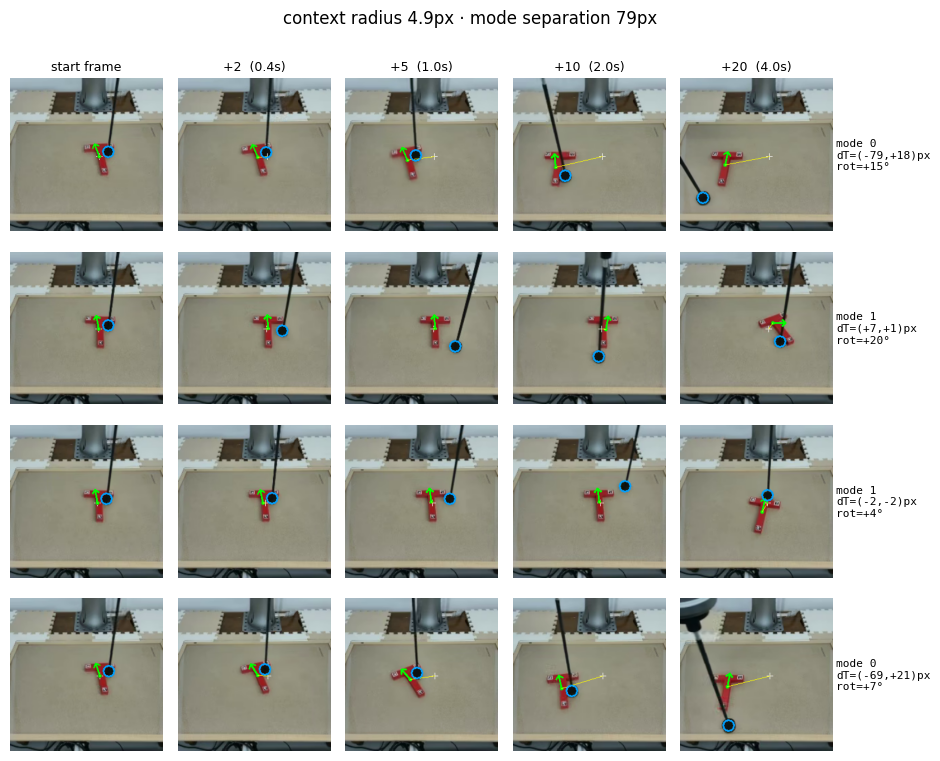

In [8]:
def show_group(g, offsets=(0, 2, 5, 10, 20), scale=1.9):
    n, k = len(g['members']), len(offsets)
    fig, axes = plt.subplots(n, k, figsize=(scale*k, scale*n), squeeze=False)
    for row, m in enumerate(g['members']):
        with h5py.File(shard_path(m['shard']), 'r') as f:
            ln = int(f['episode_lengths'][0])
            imgs = f['images'][0, m['frame']:min(m['frame'] + max(offsets) + 1, ln)]
        ref = (m['ctx'][0], m['ctx'][1])
        for col, o in enumerate(offsets):
            ax = axes[row][col]
            ax.imshow(annotate(imgs[min(o, len(imgs)-1)], ref=ref)); ax.axis('off')
            if row == 0:
                ax.set_title(f'+{o}  ({o*DT:.1f}s)' if o else 'start frame', fontsize=9)
        axes[row][0].set_ylabel(f"ep{m['shard']} f{m['frame']}")
        axes[row][-1].text(1.02, 0.5, f"mode {m['mode']}\ndT=({m['out'][0]:+.0f},{m['out'][1]:+.0f})px\n"
                           f"rot={np.degrees(m['out'][2]/RHO):+.0f}°",
                           transform=axes[row][-1].transAxes, va='center', fontsize=8, family='monospace')
    fig.suptitle(f"context radius {g['ctx_r']:.1f}px · mode separation {g['sep']:.0f}px", y=1.0)
    plt.tight_layout(); plt.show()


show_group(groups[0])

## 7. The empirical modes

For each group, the members' outcomes **are** the reference distribution: this is what the
data says can happen from that frame. A sampler conditioned on the same frame should put
mass near each of them, in roughly the observed proportion — not on their mean.

Sample sizes are small (3–5 sessions per group), so treat these as *witnessed* modes, not a
calibrated density: they prove the mode exists, they do not measure its probability well.

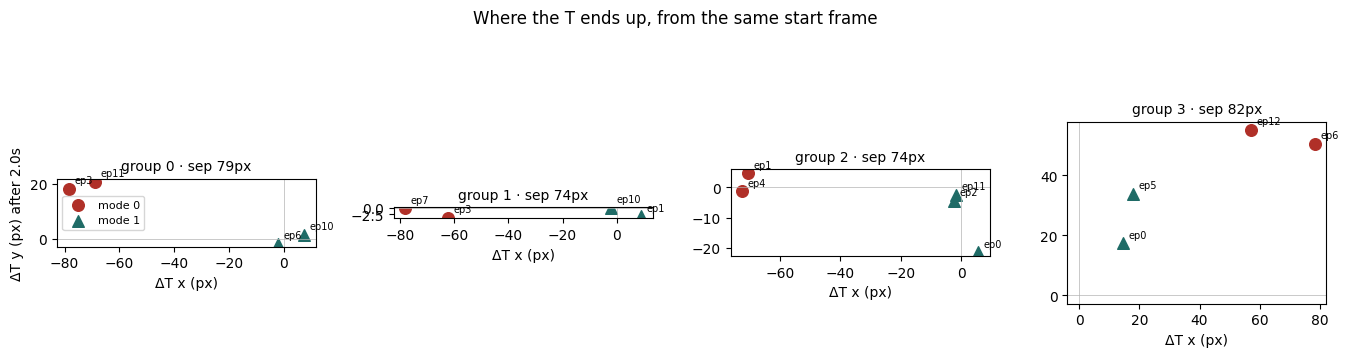

group 0: {0: 'n=2 mean=(-74,+19)px', 1: 'n=2 mean=(+3,-0)px'}
group 1: {0: 'n=2 mean=(-70,-2)px', 1: 'n=2 mean=(+3,-2)px'}
group 2: {0: 'n=2 mean=(-72,+2)px', 1: 'n=3 mean=(+0,-9)px'}
group 3: {0: 'n=2 mean=(+68,+53)px', 1: 'n=2 mean=(+16,+26)px'}


In [9]:
def mode_summary(g):
    """Per-mode mean outcome and member count."""
    out = {}
    for m in g['members']:
        out.setdefault(m['mode'], []).append(m['out'])
    return {k: dict(n=len(v), mean=np.mean(v, 0)) for k, v in out.items()}


ncol = min(4, len(groups))
fig, axes = plt.subplots(1, ncol, figsize=(3.4*ncol, 3.6), squeeze=False)
for gi in range(ncol):
    g, ax = groups[gi], axes[0][gi]
    for m in g['members']:
        ax.scatter(m['out'][0], m['out'][1], s=70, marker='o' if m['mode'] == 0 else '^',
                   c='#b03028' if m['mode'] == 0 else '#1f6b66',
                   label=f"mode {m['mode']}")
        ax.annotate(f"ep{m['shard']}", (m['out'][0], m['out'][1]), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')
    ax.axhline(0, lw=.5, c='0.7'); ax.axvline(0, lw=.5, c='0.7')
    ax.set_title(f'group {gi} · sep {g["sep"]:.0f}px', fontsize=10)
    ax.set_xlabel('ΔT x (px)'); ax.set_aspect('equal')
    if gi == 0:
        ax.set_ylabel(f'ΔT y (px) after {H_GROUP*DT:.1f}s')
        h, l = ax.get_legend_handles_labels()
        ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=8)
fig.suptitle('Where the T ends up, from the same start frame', y=1.02)
plt.tight_layout(); plt.show()

for gi, g in enumerate(groups[:ncol]):
    print(f'group {gi}:', {k: f"n={v['n']} mean=({v['mean'][0]:+.0f},{v['mean'][1]:+.0f})px"
                           for k, v in mode_summary(g).items()})

## 8. Export

Two files:

- **`multimodal_contexts.json`** — every group with `(shard, frame)`, the context descriptor,
  each member's outcome and mode label. Use this with `encode_context_from_frame` below.
- **`pushT_multimodal.yaml`** — the same anchors in the init format
  `study/data.load_curated_contexts` reads, so the sweep can consume them directly. This needs
  each frame expressed as a `(window_idx, t0)` into a `ShardedHDF5Dataset`, so the mapping is
  built from `dataset.windows`. Frames in episodes the split holds out cannot be expressed and
  are reported as skipped. `start_center_fingerprint` is the loader's drift tripwire — the
  `score_t_centered` centre score of the decision frame.

In [10]:
json_path = OUT_DIR / 'multimodal_contexts.json'
json_path.write_text(json.dumps(dict(
    dataset=str(DATA_DIR), H=H_GROUP, dt=DT, rho=RHO, tau=GROUP_TAU, contact=CONTACT,
    note='outcome = (dcx, dcy, rho*dphi) of the T over H frames, image pixels',
    groups=groups), indent=1))
print('wrote', json_path.resolve())

wrote /home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/notebooks/multimodal_contexts.json


In [11]:
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.planning.reward import score_t_centered

DS_KW = dict(window_size=64, stride=1, split='train', train_fraction=0.9,
             split_seed=123, shuffle_windows=False)      # must match the sweep's dataset block
Tc = 8              # context frames the init carries
MIN_FUTURE = 32     # ground-truth frames to keep after the decision frame, inside the window

ds = ShardedHDF5Dataset(data_dir=str(DATA_DIR), **DS_KW)
win_index = {(s, start): w for w, (s, ep, start) in enumerate(ds.windows)}


def frame_to_window(shard, frame, Tc=Tc, window_size=64, min_future=MIN_FUTURE):
    """(shard, frame) -> (window_idx, t0) with frame == window_start + t0 + Tc - 1.

    Prefers the largest t0 that still leaves `min_future` ground-truth frames after the
    decision frame. Returns None when the frame's episode is not in this split.
    """
    for t0 in range(window_size - Tc - min_future, -1, -1):
        start = frame - (t0 + Tc - 1)
        if start < 0:
            continue
        w = win_index.get((shard, start))
        if w is not None:
            return w, t0
    return None


lines = ['# Multi-modal initial contexts: real frames whose continuation the dataset itself',
         '# disagrees about. Generated by notebooks/investigate-dataset.ipynb.',
         '# An init = a decision point: Tc context frames ending at the decision frame.',
         '# window_idx is a ShardedHDF5Dataset index under the dataset block below.',
         '', 'dataset:', f'  data_dir: {DATA_DIR}']
for k, v in DS_KW.items():
    lines.append(f'  {k}: {v}')
lines += [f'Tc: {Tc}', 'reward_kind: center', '', 'inits:']

n_ok = n_skip = 0
for gi, g in enumerate(groups):
    for m in g['members']:
        wt = frame_to_window(m['shard'], m['frame'])
        if wt is None:
            n_skip += 1
            print(f"  skipped ep{m['shard']} f{m['frame']} — episode not in split '{DS_KW['split']}'")
            continue
        w, t0 = wt
        with h5py.File(shard_path(m['shard']), 'r') as f:
            rgb = f['images'][0, m['frame']]
        fp = float(score_t_centered(rgb)[0])
        lines.append(f"  - {{id: {n_ok}, window_idx: {w}, t0: {t0}, "
                     f"start_center_fingerprint: {fp:.3f}, "
                     f"label: \"group{gi} mode{m['mode']} ep{m['shard']}f{m['frame']}\"}}")
        n_ok += 1

yaml_path = OUT_DIR / 'pushT_multimodal.yaml'
yaml_path.write_text('\n'.join(lines) + '\n')
print(f'wrote {yaml_path.resolve()} — {n_ok} inits, {n_skip} skipped')
print(f'to use it with the sweep: cp {yaml_path} ../study/config/inits/')

Train split: 64694 windows from 11 episodes
  skipped ep3 f5458 — episode not in split 'train'
  skipped ep3 f4924 — episode not in split 'train'
  skipped ep3 f4784 — episode not in split 'train'
  skipped ep9 f3162 — episode not in split 'train'
wrote /home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/notebooks/pushT_multimodal.yaml — 30 inits, 4 skipped
to use it with the sweep: cp pushT_multimodal.yaml ../study/config/inits/


## 9. Hand-off: conditioning a rollout on one of these frames

`encode_context_from_frame` reads `Tc` frames ending at a chosen frame straight from the
shard and encodes them — no `ShardedHDF5Dataset` indexing, no split to worry about. It
returns exactly the `(ctx_z, ctx_a)` pair the planning rollout primitives take.

Then the test the whole notebook exists for: sample many rollouts from one multi-modal start
frame, decode the final horizon frame of each, measure where the T went, and compare that
spread against the modes the sessions actually took.

In [12]:
import torch
from torch.nn.functional import interpolate
from hydra import initialize, compose
from dreamerv4uwm.models.utils import load_tokenizer, load_denoiser

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

with initialize(version_base=None, config_path='../../../../scripts/config'):
    cfg = compose(config_name='dynamics/pushT-large', overrides=['denoiser.horizon_aware=false'])
cfg.dynamics_ckpt   = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/blockcausal/pushT-post-train/97500.pt'
cfg.tokenizer_ckpt  = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/pushT.pt'

denoiser  = load_denoiser(cfg, device, max_num_forward_steps=300).eval()
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300).eval()
print('loaded')

/home/mim-server/miniconda3/envs/dreamerv4uwm/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT-large': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


loaded


In [13]:
@torch.no_grad()
def encode_context_from_frame(shard, frame, Tc=8, n_actions=None, resolution=(256, 256)):
    """`Tc` frames ending at `frame` -> (ctx_z (1,Tc,N,D), ctx_a (1,Tc,n_act)).

    Actions are stored as the delta applied *at* each frame, so the context actions are the
    ones belonging to the context frames — same alignment as ShardedHDF5Dataset windows.
    """
    n_actions = n_actions or cfg.denoiser.n_actions
    lo = frame - Tc + 1
    assert lo >= 0, f'need {Tc} frames of history before frame {frame}'
    with h5py.File(shard_path(shard), 'r') as f:
        imgs = f['images'][0, lo:frame + 1]                       # (Tc,H,W,3) uint8
        acts = f['actions'][0, lo:frame + 1, :n_actions]          # (Tc,n_act)
    x = torch.from_numpy(imgs).float().permute(0, 3, 1, 2) / 255.0
    x = interpolate(x, resolution).to(device)[None]               # (1,Tc,3,H,W)
    with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
        z = tokenizer.encode(x).float()
    return z, torch.from_numpy(acts).float().to(device)[None]


@torch.no_grad()
def decode_frames(z, max_batch=32):
    """(M, N_lat, D_lat) latents -> (M, 256, 256, 3) uint8 RGB."""
    out = []
    for s in range(0, z.shape[0], max_batch):
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            img = tokenizer.decode(z[s:s+max_batch][:, None]).float().clamp(0, 1)[:, 0]
        out.append((img.permute(0, 2, 3, 1) * 255).to(torch.uint8).cpu().numpy())
    return np.concatenate(out)


def t_delta_from_rgb(rgb_end, start_ctx):
    """T-pose displacement of a decoded frame relative to a group member's start context."""
    t = t_pose(rgb_end)
    if not t['found']:
        return None
    phi0 = np.arctan2(start_ctx[3], start_ctx[2])
    dphi = (t['phi'] - phi0 + np.pi) % (2*np.pi) - np.pi
    return np.array([t['cx'] - start_ctx[0], t['cy'] - start_ctx[1], RHO*dphi])

In [14]:
from dreamerv4uwm.planning.rollout import imagine

GROUP = 0                        # which group to condition on
B     = 32                       # rollouts to sample
K     = 12                       # Euler steps
TC_ROLLOUT = 1                   # context frames given to the model — see the note below
anchor = groups[GROUP]['members'][0]

ctx_z, ctx_a = encode_context_from_frame(anchor['shard'], anchor['frame'], Tc=TC_ROLLOUT)
z_hor, a_hor = imagine(denoiser, ctx_z, ctx_a, H=H_GROUP, B=B, K=K,
                       generator=torch.Generator(device=device).manual_seed(0))
print('sampled', tuple(z_hor.shape))

ends = decode_frames(z_hor[:, -1])                                  # last horizon frame of each rollout
model_out = [t_delta_from_rgb(e, anchor['ctx']) for e in ends]
model_out = np.stack([m for m in model_out if m is not None])
print(f'{len(model_out)}/{B} rollouts had a segmentable T')

sampled (32, 10, 256, 32)
32/32 rollouts had a segmentable T


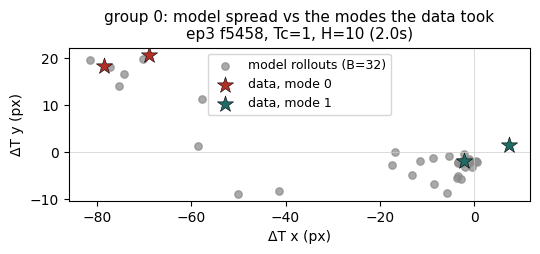

model: mean radius 26.4px, median pairwise distance 21.8px
data : 4 sessions, modes 79px apart
  mode 0 (n=2, mean (-74,+19)px): nearest rollout 2.9px, 22% of rollouts within half the mode separation
  mode 1 (n=2, mean (+3,-0)px): nearest rollout 4.6px, 72% of rollouts within half the mode separation


In [15]:
g = groups[GROUP]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(model_out[:, 0], model_out[:, 1], s=28, c='0.55', alpha=.75,
           label=f'model rollouts (B={len(model_out)})')
for m in g['members']:
    ax.scatter(m['out'][0], m['out'][1], s=150, marker='*',
               c='#b03028' if m['mode'] == 0 else '#1f6b66',
               edgecolor='k', linewidth=.4, zorder=3, label=f"data, mode {m['mode']}")
ax.axhline(0, lw=.5, c='0.8'); ax.axvline(0, lw=.5, c='0.8')
ax.set_xlabel('ΔT x (px)'); ax.set_ylabel('ΔT y (px)'); ax.set_aspect('equal')
h, l = ax.get_legend_handles_labels()
ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), fontsize=9)
ax.set_title(f'group {GROUP}: model spread vs the modes the data took\n'
             f'ep{anchor["shard"]} f{anchor["frame"]}, Tc={TC_ROLLOUT}, H={H_GROUP} ({H_GROUP*DT:.1f}s)',
             fontsize=11)
plt.tight_layout(); plt.show()

# Two spread readouts: the mean radius, and the median pairwise distance — the latter is
# the same quantity section 4 reports for the data, so the two are directly comparable.
from itertools import combinations
pair_d = np.array([np.linalg.norm(model_out[a] - model_out[b])
                   for a, b in combinations(range(len(model_out)), 2)])
modes = mode_summary(g)
print(f'model: mean radius {np.linalg.norm(model_out - model_out.mean(0), axis=1).mean():.1f}px, '
      f'median pairwise distance {np.median(pair_d):.1f}px')
print(f'data : {len(g["members"])} sessions, modes {g["sep"]:.0f}px apart')
for k, v in modes.items():
    d = np.linalg.norm(model_out - v['mean'], axis=1)
    print(f'  mode {k} (n={v["n"]}, mean ({v["mean"][0]:+.0f},{v["mean"][1]:+.0f})px): '
          f'nearest rollout {d.min():.1f}px, {100*(d < g["sep"]/2).mean():.0f}% of rollouts within '
          f'half the mode separation')

### Context length is part of the question

`TC_ROLLOUT` decides which ambiguity is being tested, so it has to match the one the group
was built on. The groups above match on **one** frame, so `TC_ROLLOUT = 1` is the like-for-like
test; a longer context hands the model the approach velocity, which section 4 shows resolves
much of the short-horizon ambiguity in the data too.

Running this notebook on group 0 (two modes 79 px apart, 4 sessions) gave:

| anchor | Tc | model mean ΔT | spread (mean radius) | nearest to mode 0 | nearest to mode 1 |
|---|---|---|---|---|---|
| ep3 f5458 (its session took mode 0) | 1 | (−21.9, +0.5) px | 26.4 px | 2.9 px | 4.6 px |
| ep3 f5458 | 8 | (−75.8, +17.5) px | 1.0 px | 2.9 px | 78.1 px |
| ep10 f5232 (its session took mode 1) | 1 | (−1.9, −1.0) px | 7.3 px | 19.7 px | 2.3 px |
| ep10 f5232 | 8 | (+7.2, +1.2) px | 0.7 px | 76.1 px | 5.3 px |

At `Tc=1` the sampler covers both modes from the ep3 frame — the multimodality is recovered.
At `Tc=8` it collapses to a ~1 px cloud on whichever mode *that member's own session* took.
The collapse is not justified by the data: section 4's paired control says 8 frames of history
cut the divergence between matched futures by only 8% at this horizon, leaving ~13.7 px of
genuine spread, against the model's 1 px.

Worth checking before drawing conclusions: `H_GROUP=10` at `K=12` is one short edge — the
spread may depend on `K`, on `action_temp`, and on `imagine` vs `autoregressive`.

In [16]:
# Sweep the two knobs that decide what is being measured: which member's frame, and how many
# context frames it gets. Same modes, same horizon.
g, modes = groups[GROUP], mode_summary(groups[GROUP])
print(f"{'anchor':>22} {'Tc':>3} | {'model mean dT':>19} {'spread':>8} | "
      f"{'d(mode0)':>9} {'d(mode1)':>9}")
for m in g['members'][:2]:
    for tc in (1, 8):
        cz, ca = encode_context_from_frame(m['shard'], m['frame'], Tc=tc)
        zh, _ = imagine(denoiser, cz, ca, H=H_GROUP, B=B, K=K,
                        generator=torch.Generator(device=device).manual_seed(0))
        o = [t_delta_from_rgb(e, m['ctx']) for e in decode_frames(zh[:, -1])]
        o = np.stack([x for x in o if x is not None])
        mu = o.mean(0)
        d = {k: np.linalg.norm(o - v['mean'], axis=1).min() for k, v in modes.items()}
        print(f"ep{m['shard']:>2} f{m['frame']:<5} (mode {m['mode']}) {tc:>3} | "
              f"({mu[0]:+7.1f},{mu[1]:+7.1f})px {np.linalg.norm(o - mu, axis=1).mean():>7.1f}px | "
              f"{d[0]:>8.1f}px {d[1]:>8.1f}px")

                anchor  Tc |       model mean dT   spread |  d(mode0)  d(mode1)
ep 3 f5458  (mode 0)   1 | (  -21.9,   +0.5)px    26.4px |      2.9px      4.6px
ep 3 f5458  (mode 0)   8 | (  -75.8,  +17.5)px     1.0px |      2.9px     78.1px
ep10 f5232  (mode 1)   1 | (   -1.9,   -1.0)px     7.3px |     19.7px      2.3px
ep10 f5232  (mode 1)   8 | (   +7.2,   +1.2)px     0.7px |     76.1px      5.3px


## Caveats

- Everything is in **image pixels from one fixed camera**, not table coordinates; distances
  near the far edge are compressed relative to the near edge.
- The context descriptor is T pose + end-effector position only. Two frames matching to 5 px
  can still differ in the arm's configuration above the table, which the camera sees and the
  descriptor ignores — worth a glance at the filmstrip before trusting a group.
- Heading resolves its 180° ambiguity from the crossbar's wider spread; it flips on 0.44% of
  consecutive frames. `MIN_CONF` filters the frames where that call is unreliable.
- 3–5 members per group is enough to witness a mode, not to estimate its probability.
- Group membership is anchored on a *single* frame. Members share the visible state, not the
  approach velocity — which, per section 4, changes the short-horizon outcome much more than
  the long-horizon one. Condition rollouts with `TC_ROLLOUT=1` to test that same ambiguity;
  a longer context is a different question with a different (narrower) empirical answer.